In [1]:
import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font

big_plt_font()
rm = visa.ResourceManager()
## uncomment the following if full address not known
# instruments = rm.list_resources() 
# usb = list(filter(lambda x: 'USB' in x, instruments))
SSA = rm.open_resource('TCPIP::192.168.169.161::INSTR')
print(SSA.query("*IDN?"))

Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10



In [27]:
freq_center = 151.4 # MHz
freq_span = 1 # MHz
RBW_AUTO = 0 #1-ON, 0-OFF
VBW_AUTO = 1 #1-ON, 0-OFF
SWT_AUTO = 1 #1-ON, 0-OFF
VBW_RBW_RAT = 10 
RBW = 0.1 #kHz
VBW = 0.1 #kHz
SWT = 1 #ms
N_AVG = 10

In [28]:
# Configure frequency
SSA.write("SENS:FREQ:CENT " + str(freq_center) + " MHz")
SSA.write("SENS:FREQ:SPAN " + str(freq_span) + " MHz")

# Configure bandwidths and sweep time
SSA.write("SENS:BWID:AUTO " + str(RBW_AUTO))
SSA.write("SENS:BWID:VID:AUTO " + str(VBW_AUTO))
SSA.write("SENS:SWE:TIME:AUTO " + str(SWT_AUTO))
SSA.write("SENS:BWID:VID " + str(VBW) + " kHz")
SSA.write("SENS:BWID " + str(RBW) + " kHz")
SSA.write("SENS:BWID:VID:RAT " + str(VBW_RBW_RAT))
SSA.write("SENS:SWE:TIME " + str(SWT) + " ms")

# Set sweep mode to FFT
SSA.write(":SWEep:MODE FFT")

# Set averaging ON and number of averages = 100
SSA.write(f":AVERage:TRACe1:COUNt  {N_AVG}")
SSA.write(f":AVERage:TRACe3:COUNt {N_AVG}")
time.sleep(SWT*1e-3*N_AVG)

# Set power unit to dBm
SSA.write("UNIT:POW DBM")

14

In [77]:
SSA.write(":AVERage:TRAC1:CLEar")
while int(SSA.query(":AVERage:TRACe1?")) < N_AVG: 
     continue
data_str_A = SSA.query(":TRACe1:DATA?")
data_arr_A = np.array([float(val) for val in data_str_A.split(',')])

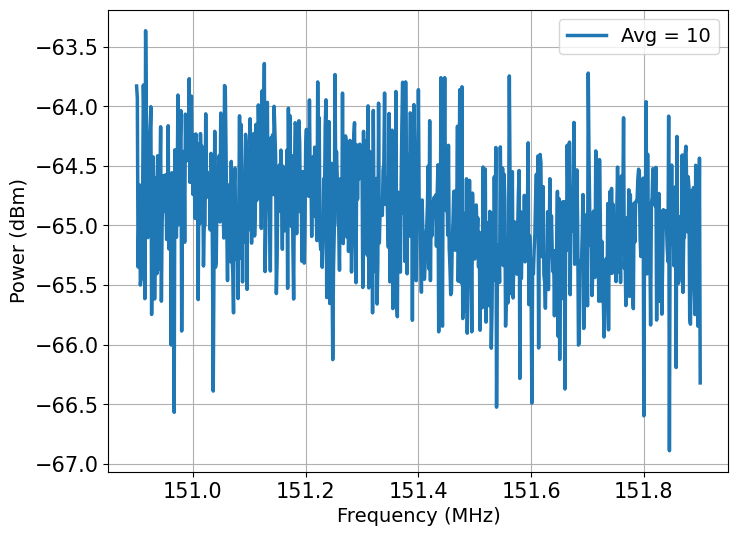

In [78]:
# Number of points in the trace
num_points = len(data_arr_A)

# Generate frequency axis in MHz
freq_start = freq_center - freq_span / 2
freq_stop  = freq_center + freq_span / 2
freq_axis = np.linspace(freq_start, freq_stop, num_points)

# --- Plot ---
plt.figure(figsize=(8,6))
plot(freq_axis, data_arr_A, label="Avg = 10")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")
plt.grid(True)
plt.legend()
plt.show()

In [79]:
np.mean(data_arr_A)

np.float64(-64.91362206391479)

In [46]:
def measure_and_plot_S11_S21(vna): 

    # Make sure VNA mode is active
    vna.write(":INSTrument:SELect VNA")
    vna.write(":INITiate:IMMediate")
    
    vna.write(":CALCulate1:PARameter1:SELect ")
    vna.write(":CALCulate1:FORMat MLOGarithmic")
    
    data_str = vna.query(":CALCulate1:DATA:FDATa?")
    data = np.array(data_str.strip().split(','), dtype=float)
    f, S11_mag = data[0::2], data[1::2]
    vna.write(":CALCulate1:PARameter2:SELect ")
    vna.write(":CALCulate1:FORMat MLOGarithmic")
    data_str = vna.query(":CALCulate1:DATA:FDATa?")
    data = np.array(data_str.strip().split(','), dtype=float)
    f, S21_mag = data[0::2], data[1::2]

    plot(f/1e9, S11_mag, label='S11')
    plot(f/1e9, S21_mag, xlabel='f (GHz)', ylabel='|S| (dB)', label='S21')
    plt.legend()
    return f, S11_mag, S21_mag

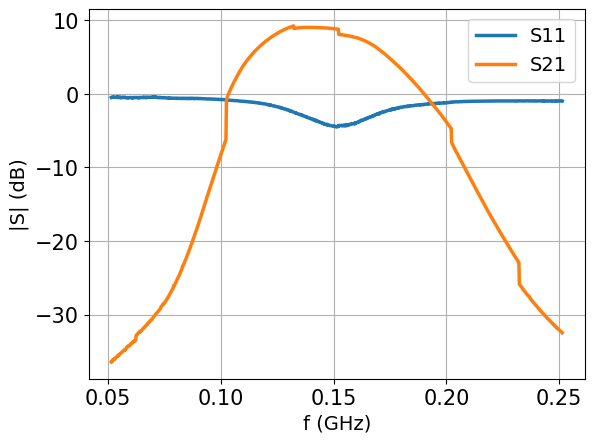

In [82]:
f, S11, S21 = measure_and_plot_S11_S21(SSA)

In [83]:
S21[np.argmin(abs(f-151.4e6))]

np.float64(8.835801)

In [72]:
def calculate_noise_parameters(p_in_dbm, gain_db, p_out_dbm, t0=290.0):
    """
    Calculates Noise Figure and Equivalent Noise Temperature.
    
    Parameters:
    p_in_dbm (float): Measured input noise power in dBm
    gain_db (float): Gain of the amplifier in dB
    p_out_dbm (float): Measured output power in dBm
    t0 (float): Reference temperature in Kelvin (default 290K)
    """
    
    # 1. Calculate Noise Figure (NF) in dB
    # NF_dB = Pout_dBm - (Pin_dBm + Gain_dB)
    nf_db = p_out_dbm - gain_db - p_in_dbm
    
    # 2. Convert Noise Figure to Linear Noise Factor (F)
    f_linear = 10**(nf_db / 10.0)
    
    # 3. Calculate Equivalent Noise Temperature (Te)
    te = t0 * (f_linear - 1)
    
    return nf_db, te

In [85]:
calculate_noise_parameters(-70.10753784287617, 7.747595, -60.56132, t0=4)

(1.7986228428761706, 2.052325484018872)